## COMPAS - 3 OBJECTIVES

### Logistic Regression

* **Dataset:** Compass
* **Task:** Classification
* **Target:** Two year recidivism
* **Objectives:** Non-white and White individuals and Regularization coefficient

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

In [3]:
from ml_moo import moo
from ml_moo import get_objectives, get_models
from ml_moo.analysis.visualization import plot_pareto_3d
from ml_moo.analysis.metrics import compute_hypervolume_progress

from scalarization import LogRegScalarization

### Dataset and Model

In [4]:
# Setting a seed for reproducibility
seed = 42

In [ ]:
data = pd.read_csv("dataset/compas_onerace.csv")
data = data.drop("Unnamed: 0", axis=1)

fair_feature = "not_white"
pred_feature = "Two_yr_Recidivism"

categories_fair_class = []

for index, row in data.iterrows():
    if row[pred_feature] == -1:
        categories_fair_class.append(row[fair_feature])
    else:
        categories_fair_class.append(row[fair_feature]+2)

X = data.drop([pred_feature], axis=1)
# y = data[pred_feature]
y = (data[pred_feature] + 1)//2

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = int(data.shape[0]*0.5),
                                                    stratify = categories_fair_class,
                                                    random_state = seed)

In [6]:
#tol = 10**-3
#max_iter = 100

tol = 10**-8
max_iter = 10000

## MOO Modeling and Training

* MOO methods:
    * MOLA
    * MONISE
    * Random Weights

In [7]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 300,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
num_objs = 3
results = {}

In [8]:
# Logistic Regression with equal weight to use as baseline model
equal = LogRegScalarization(num_objs=3,
                            X=X_train, 
                            y=y_train, 
                            fair_feat=fair_feature,
                            #tol=tol, max_iter=max_iter
                            )
equal.optimize(np.array([1/3, 1/3, 1/3]))

## MOLA

00:59:02 | DEBUG | ml_moo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 300, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
00:59:02 | DEBUG | ml_moo | Finding 1th individual minimum
00:59:02 | DEBUG | ml_moo | Finding 2th individual minimum
00:59:02 | DEBUG | ml_moo | Finding 3th individual minimum
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:447: RuntimeWarning: divide by zero encountered in scalar divide
  l2_reg_strength = 1.0 / (C * sw_sum)
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:323: RuntimeWarning: invalid value encountered in scalar divide
  loss = loss.sum() / sw_sum
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:326: RuntimeWarning: invalid value encountered in divide
  grad_pointwise /= sw_sum
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/s

new solution added [0.61523737 0.61798065 0.79301504]
new solution added [0.61294861 0.61946406 0.8736994 ]
new solution added [0.61619779 0.623516   0.47036796]
new solution added [0.6198986  0.62236668 0.39085034]
new solution added [0.61897966 0.62674465 0.31790512]


00:59:02 | DEBUG | ml_moo | Calculated weights: [6.07407410e-05 9.43324301e-01 5.66149587e-02]
00:59:02 | DEBUG | ml_moo | Importance: 0.0033721105863881995
00:59:02 | DEBUG | ml_moo | Global lower bound (y*): [0.6124441  0.61659402 0.31790512]
00:59:02 | DEBUG | ml_moo | Iteration 6
00:59:02 | DEBUG | ml_moo | Solutions list: [array([0.61897966, 0.62674465, 0.31790512]), array([0.6198986 , 0.62236668, 0.39085034]), array([0.61619779, 0.623516  , 0.47036796]), array([0.61294861, 0.61946406, 0.8736994 ]), array([0.61523737, 0.61798065, 0.79301504]), array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 0.61659402, 1.33842217]), array([0.61450545, 0.61659402, 1.33842217])]
00:59:02 | DEBUG | ml_moo | Calculated weights: [0.9345191 0.        0.0654809]
00:59:02 | DEBUG | ml_moo | Importance: 0.004445972858895697
00:59:02 | DEBUG | ml_moo | Global lower bound (y*): [0.6124441  0.61659402 0.24221253]
00:59:02 | DEBUG | ml_moo | Iteration 7
00:59:02 | DEBUG | ml_moo | Solutions lis

new solution added [0.62428337 0.62582969 0.24221253]
new solution added [0.62193762 0.63009816 0.21417833]
new solution added [0.63338497 0.63318518 0.08269667]


00:59:02 | DEBUG | ml_moo | Calculated weights: [0.91990887 0.         0.08009113]
00:59:02 | DEBUG | ml_moo | Importance: 0.008917189208868304
00:59:02 | DEBUG | ml_moo | Global lower bound (y*): [0.6124441  0.61659402 0.08269667]
00:59:02 | DEBUG | ml_moo | Iteration 9
00:59:02 | DEBUG | ml_moo | Solutions list: [array([0.63338497, 0.63318518, 0.08269667]), array([0.62193762, 0.63009816, 0.21417833]), array([0.62428337, 0.62582969, 0.24221253]), array([0.61897966, 0.62674465, 0.31790512]), array([0.6198986 , 0.62236668, 0.39085034]), array([0.61619779, 0.623516  , 0.47036796]), array([0.61294861, 0.61946406, 0.8736994 ]), array([0.61523737, 0.61798065, 0.79301504]), array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 0.61659402, 1.33842217]), array([0.61450545, 0.61659402, 1.33842217])]
00:59:02 | DEBUG | ml_moo | Calculated weights: [0.89964692 0.         0.10035308]
00:59:02 | DEBUG | ml_moo | Importance: 0.008720778971207044
00:59:02 | DEBUG | ml_moo | Global lower bou

...

new solution dominated [0.62168929 0.62981862 0.22138113]
new solution dominated [0.62168929 0.62981862 0.22138113]


00:59:06 | DEBUG | ml_moo | Calculated weights: [0.93645445 0.         0.06354555]
00:59:06 | DEBUG | ml_moo | Importance: 0.003536535346915781
00:59:06 | DEBUG | ml_moo | Global lower bound (y*): [0.6124441  0.61659402 0.07955242]
00:59:06 | DEBUG | ml_moo | Iteration 47
00:59:06 | DEBUG | ml_moo | Solutions list: [array([0.62168929, 0.62981862, 0.22138113]), array([0.62901917, 0.63801597, 0.07955242]), array([0.6257029 , 0.63431164, 0.12842343]), array([0.62366862, 0.63203985, 0.16980196]), array([0.63338497, 0.63318518, 0.08269667]), array([0.62193762, 0.63009816, 0.21417833]), array([0.62428337, 0.62582969, 0.24221253]), array([0.61897966, 0.62674465, 0.31790512]), array([0.6198986 , 0.62236668, 0.39085034]), array([0.61619779, 0.623516  , 0.47036796]), array([0.61294861, 0.61946406, 0.8736994 ]), array([0.61523737, 0.61798065, 0.79301504]), array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 0.61659402, 1.33842217]), array([0.61450545, 0.61659402, 1.33842217])]
00:59:0

new solution dominated [0.62168929 0.62981862 0.22138113]
new solution dominated [0.62168929 0.62981862 0.22138113]
new solution dominated [0.62168929 0.62981862 0.22138113]


00:59:06 | DEBUG | ml_moo | Calculated weights: [0.93645445 0.         0.06354555]
00:59:06 | DEBUG | ml_moo | Importance: 0.003536535346915781
00:59:06 | DEBUG | ml_moo | Global lower bound (y*): [0.6124441  0.61659402 0.07955242]
00:59:06 | DEBUG | ml_moo | Iteration 50
00:59:06 | DEBUG | ml_moo | Solutions list: [array([0.62168929, 0.62981862, 0.22138113]), array([0.62901917, 0.63801597, 0.07955242]), array([0.6257029 , 0.63431164, 0.12842343]), array([0.62366862, 0.63203985, 0.16980196]), array([0.63338497, 0.63318518, 0.08269667]), array([0.62193762, 0.63009816, 0.21417833]), array([0.62428337, 0.62582969, 0.24221253]), array([0.61897966, 0.62674465, 0.31790512]), array([0.6198986 , 0.62236668, 0.39085034]), array([0.61619779, 0.623516  , 0.47036796]), array([0.61294861, 0.61946406, 0.8736994 ]), array([0.61523737, 0.61798065, 0.79301504]), array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 0.61659402, 1.33842217]), array([0.61450545, 0.61659402, 1.33842217])]
00:59:0

new solution dominated [0.62168929 0.62981862 0.22138113]


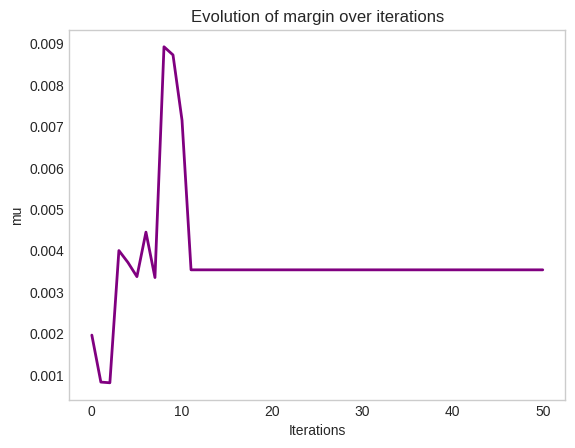

00:59:07 | INFO | ml_moo | Fit runtime: 4.76 seconds


In [9]:
method = 'mola'
w_scalar = LogRegScalarization(num_objs=3, 
                               X=X_train, 
                               y=y_train,
                               fair_feat=fair_feature,
                               tol=tol,
                               max_iter=max_iter, 
                               gradient=False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

In [10]:
objs_all = np.array([s.objs for s in moopt.history_list])

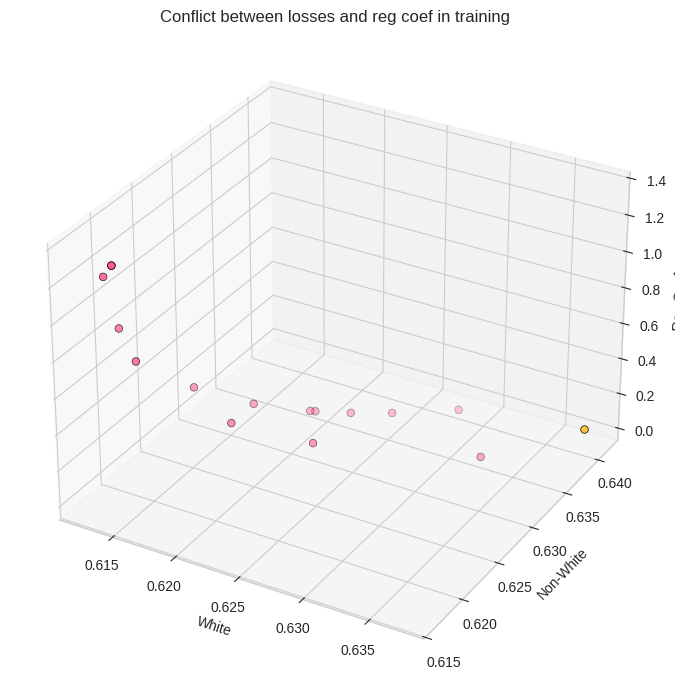

In [11]:
title = "Conflict between losses and reg coef in training"
plot_pareto_3d(objs,
               labels=("White", "Non-White", "Reg Coef"), 
               title=title,
               point = equal.objs,
               color="#FF5C8D")

00:59:07 | DEBUG | ml_moo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 300, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
00:59:07 | DEBUG | ml_moo | Finding 1th individual minimum
00:59:07 | DEBUG | ml_moo | Finding 2th individual minimum
00:59:07 | DEBUG | ml_moo | Finding 3th individual minimum
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:447: RuntimeWarning: divide by zero encountered in scalar divide
  l2_reg_strength = 1.0 / (C * sw_sum)
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:323: RuntimeWarning: invalid value encountered in scalar divide
  loss = loss.sum() / sw_sum
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:326: RuntimeWarning: invalid value encountered in divide
  grad_pointwise /= sw_sum
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/s

new solution added [0.61523737 0.61798065 0.79301504]
new solution added [0.61294861 0.61946406 0.8736994 ]
new solution added [0.61619779 0.623516   0.47036796]
new solution added [0.6198986  0.62236668 0.39085034]
new solution added [0.61897966 0.62674465 0.31790512]


00:59:07 | DEBUG | ml_moo | Calculated weights: [6.07407410e-05 9.43324301e-01 5.66149587e-02]
00:59:07 | DEBUG | ml_moo | Importance: 0.0033721105863881995
00:59:07 | DEBUG | ml_moo | Global lower bound (y*): [0.6124441  0.61659402 0.31790512]
00:59:07 | DEBUG | ml_moo | Iteration 6
00:59:07 | DEBUG | ml_moo | Solutions list: [array([0.61897966, 0.62674465, 0.31790512]), array([0.6198986 , 0.62236668, 0.39085034]), array([0.61619779, 0.623516  , 0.47036796]), array([0.61294861, 0.61946406, 0.8736994 ]), array([0.61523737, 0.61798065, 0.79301504]), array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 0.61659402, 1.33842217]), array([0.61450545, 0.61659402, 1.33842217])]
00:59:07 | DEBUG | ml_moo | Calculated weights: [0.9345191 0.        0.0654809]
00:59:07 | DEBUG | ml_moo | Importance: 0.004445972858895697
00:59:07 | DEBUG | ml_moo | Global lower bound (y*): [0.6124441  0.61659402 0.24221253]
00:59:07 | DEBUG | ml_moo | Iteration 7
00:59:07 | DEBUG | ml_moo | Solutions lis

new solution added [0.62428337 0.62582969 0.24221253]
new solution added [0.62193762 0.63009816 0.21417833]
new solution added [0.63338497 0.63318518 0.08269667]
new solution added [0.62366862 0.63203985 0.16980196]


00:59:07 | DEBUG | ml_moo | Calculated weights: [0.89964692 0.         0.10035308]
00:59:07 | DEBUG | ml_moo | Importance: 0.008720778971207044
00:59:07 | DEBUG | ml_moo | Global lower bound (y*): [0.6124441  0.61659402 0.08269667]
00:59:07 | DEBUG | ml_moo | Iteration 10
00:59:07 | DEBUG | ml_moo | Solutions list: [array([0.62366862, 0.63203985, 0.16980196]), array([0.63338497, 0.63318518, 0.08269667]), array([0.62193762, 0.63009816, 0.21417833]), array([0.62428337, 0.62582969, 0.24221253]), array([0.61897966, 0.62674465, 0.31790512]), array([0.6198986 , 0.62236668, 0.39085034]), array([0.61619779, 0.623516  , 0.47036796]), array([0.61294861, 0.61946406, 0.8736994 ]), array([0.61523737, 0.61798065, 0.79301504]), array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 0.61659402, 1.33842217]), array([0.61450545, 0.61659402, 1.33842217])]
00:59:07 | DEBUG | ml_moo | Calculated weights: [0.85616488 0.         0.14383512]
00:59:07 | DEBUG | ml_moo | Importance: 0.00714470016333279

...

new solution dominated [0.62168929 0.62981862 0.22138113]
new solution dominated [0.62168929 0.62981862 0.22138113]
new solution dominated [0.62168929 0.62981862 0.22138113]


00:59:11 | DEBUG | ml_moo | Calculated weights: [0.93645445 0.         0.06354555]
00:59:11 | DEBUG | ml_moo | Importance: 0.003536535346915781
00:59:11 | DEBUG | ml_moo | Global lower bound (y*): [0.6124441  0.61659402 0.07955242]
00:59:11 | DEBUG | ml_moo | Iteration 48
00:59:11 | DEBUG | ml_moo | Solutions list: [array([0.62168929, 0.62981862, 0.22138113]), array([0.62901917, 0.63801597, 0.07955242]), array([0.6257029 , 0.63431164, 0.12842343]), array([0.62366862, 0.63203985, 0.16980196]), array([0.63338497, 0.63318518, 0.08269667]), array([0.62193762, 0.63009816, 0.21417833]), array([0.62428337, 0.62582969, 0.24221253]), array([0.61897966, 0.62674465, 0.31790512]), array([0.6198986 , 0.62236668, 0.39085034]), array([0.61619779, 0.623516  , 0.47036796]), array([0.61294861, 0.61946406, 0.8736994 ]), array([0.61523737, 0.61798065, 0.79301504]), array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 0.61659402, 1.33842217]), array([0.61450545, 0.61659402, 1.33842217])]
00:59:1

new solution dominated [0.62168929 0.62981862 0.22138113]
new solution dominated [0.62168929 0.62981862 0.22138113]


00:59:11 | DEBUG | ml_moo | Calculated weights: [0.93645445 0.         0.06354555]
00:59:11 | DEBUG | ml_moo | Importance: 0.003536535346915781
00:59:11 | DEBUG | ml_moo | Global lower bound (y*): [0.6124441  0.61659402 0.07955242]
00:59:11 | DEBUG | ml_moo | Iteration 51
00:59:11 | DEBUG | ml_moo | Solutions list: [array([0.62168929, 0.62981862, 0.22138113]), array([0.62901917, 0.63801597, 0.07955242]), array([0.6257029 , 0.63431164, 0.12842343]), array([0.62366862, 0.63203985, 0.16980196]), array([0.63338497, 0.63318518, 0.08269667]), array([0.62193762, 0.63009816, 0.21417833]), array([0.62428337, 0.62582969, 0.24221253]), array([0.61897966, 0.62674465, 0.31790512]), array([0.6198986 , 0.62236668, 0.39085034]), array([0.61619779, 0.623516  , 0.47036796]), array([0.61294861, 0.61946406, 0.8736994 ]), array([0.61523737, 0.61798065, 0.79301504]), array([0.6124441 , 0.61857976, 1.17220873]), array([0.61450545, 0.61659402, 1.33842217]), array([0.61450545, 0.61659402, 1.33842217])]


new solution dominated [0.62168929 0.62981862 0.22138113]


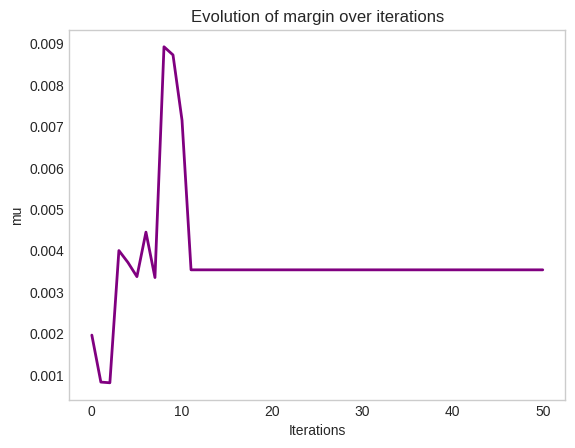

00:59:11 | INFO | ml_moo | Fit runtime: 4.71 seconds


In [12]:
# Test with gradient
method = 'mola'
w_scalar = LogRegScalarization(num_objs=3, 
                               X=X_train, 
                               y=y_train,
                               fair_feat=fair_feature,
                               tol=tol,
                               max_iter=max_iter, 
                               gradient=False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[f"{method}_grad"] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

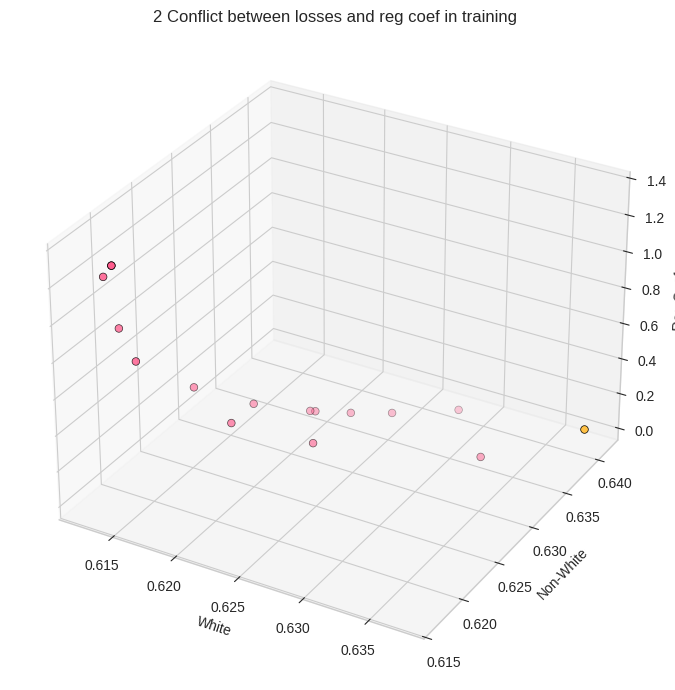

In [13]:
title = "2 Conflict between losses and reg coef in training"
plot_pareto_3d(objs,
               labels=("White", "Non-White", "Reg Coef"), 
               title=title,
               point = equal.objs,
               color="#FF5C8D")

### MONISE

In [14]:
scalarization = None
moopt = None
objs = None

In [ ]:
method = 'monise'
w_scalar = LogRegScalarization(num_objs=3, 
                               X=X_train, 
                               y=y_train,
                               fair_feat=fair_feature,
                               tol=tol,
                               max_iter=max_iter, 
                               gradient=False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

00:59:12 | DEBUG | ml_moo | Filtered parameters for monise: {'nodeTimeLimit': 2, 'targetSize': 300, 'targetGap': 0, 'nodeGap': 0.05, 'norm': False}
00:59:12 | DEBUG | ml_moo.moo.monise | Finding 1th individual minima
00:59:12 | DEBUG | ml_moo.moo.monise | Finding 2th individual minima


monise


00:59:12 | DEBUG | ml_moo.moo.monise | 3th solution - importance: 1.0
00:59:12 | DEBUG | ml_moo.moo.monise | 4th solution - importance: 1.0
00:59:12 | DEBUG | ml_moo.moo.monise | 5th solution - importance: 1.0
00:59:12 | DEBUG | ml_moo.moo.monise | 6th solution - importance: 1.0
00:59:12 | DEBUG | ml_moo.moo.monise | 7th solution - importance: 1.0
00:59:12 | DEBUG | ml_moo.moo.monise | 8th solution - importance: 0.24978549466220293
00:59:12 | DEBUG | ml_moo.moo.monise | 9th solution - importance: 0.2496785277828801
00:59:12 | DEBUG | ml_moo.moo.monise | 10th solution - importance: 0.06460221412297207


Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


00:59:12 | DEBUG | ml_moo.moo.monise | 11th solution - importance: 0.06366560470571964
00:59:12 | DEBUG | ml_moo.moo.monise | 12th solution - importance: 0.06213080729628476
00:59:12 | DEBUG | ml_moo.moo.monise | 13th solution - importance: 0.06046661142453608
00:59:12 | DEBUG | ml_moo.moo.monise | 14th solution - importance: 0.016156109494807728
00:59:12 | DEBUG | ml_moo.moo.monise | 15th solution - importance: 0.01614527976000254
00:59:13 | DEBUG | ml_moo.moo.monise | 16th solution - importance: 0.016034527856862976
00:59:13 | DEBUG | ml_moo.moo.monise | 17th solution - importance: 0.01594935989479155


...

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


01:03:51 | DEBUG | ml_moo.moo.monise | 299th solution - importance: 0.0023133877995834408


Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


01:03:53 | DEBUG | ml_moo.moo.monise | 300th solution - importance: 0.0023133877995834408


Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


### Ramdon Weighted Sum

In [16]:
method = 'random_weight'
w_scalar = LogRegScalarization(num_objs=3, 
                               X=X_train, 
                               y=y_train,
                               fair_feat=fair_feature,
                               tol=tol,
                               max_iter=max_iter, 
                               gradient=False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

01:03:55 | WARNING | ml_moo | Ignored parameters for random_weights: {'nodeGap', 'targetGap', 'nodeTimeLimit'}
01:03:55 | DEBUG | ml_moo | Filtered parameters for random_weights: {'targetSize': 300, 'norm': False}
01:03:55 | DEBUG | ml_moo.moo.random_weights | Finding 1th individual minima
01:03:55 | DEBUG | ml_moo.moo.random_weights | Finding 2th individual minima
01:03:55 | DEBUG | ml_moo.moo.random_weights | Finding 3th individual minima
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:447: RuntimeWarning: divide by zero encountered in scalar divide
  l2_reg_strength = 1.0 / (C * sw_sum)
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:323: RuntimeWarning: invalid value encountered in scalar divide
  loss = loss.sum() / sw_sum
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:326: RuntimeWarning: invalid

## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

In [17]:
from ml_moo.analysis.moo_analyzer import Analyzer

In [18]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

colors_pareto = ['#FF5C8D', '#FF5C8D', '#FF5C8D']
colors_hv = ['#FF5C8D', '#FF5C8D', '#4BD6A0', '#9D5CFF']
title = ""
axis_label = ["White", "Non-White", "Regularization coefficient"]

Analyzer.run_multiple(pareto_dict = pareto_dict,
                      hypervolumes_values = hypervolumes_dict,
                      show_pareto = True, 
                      show_hypervolume = True,
                      subplots = True,
                      subplots_hv = True,
                      colors_pareto=colors_hv,
                      colors_hv=colors_hv,
                      point = equal.objs,
                      axis_label=axis_label,
                      #num_views = 3,
                      )

ValueError: Method 'monise' has 2 objectives, expected 3.